# Object segmentation network

## Table of Contents

### Import libraries


In [1]:
from torch.utils.data import Dataset
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches


<a id="Initialize-the-data-loader"></a>
### Data loader implementation

In [2]:
from clases.model_utils import *

### Initialize the data loader

In [3]:
train_dataset, test_dataset = prepare_dataset()
# Create a DataLoader to iterate through the dataset
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

Windows
train dir: C:\Users\pol\repos\TFG\code\src\clases\../../data/TrainValid/TrainValid
test dir: C:\Users\pol\repos\TFG\code\src\clases\../../data/Test/Test


### Test the data loader
(re-run this cell to see different examples)

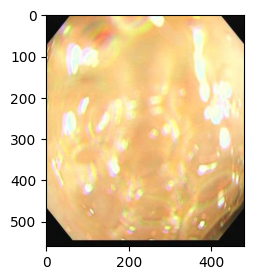

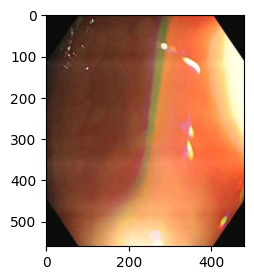

tensor([[227., 147., 311., 236.]])


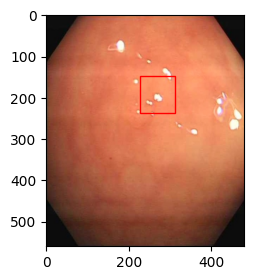

tensor([[ 83., 184., 246., 363.]])


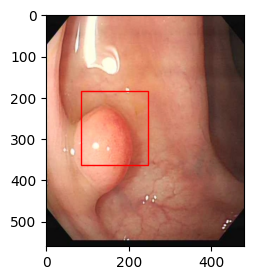

tensor([[106., 162., 380., 427.]])


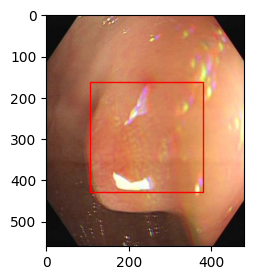

In [4]:
max_images_to_display = 5  # Set the maximum number of images to display
image_counter = 0    # Initialize a counter

# Set the desired figure size
fig_width, fig_height = 4, 3  # Adjust these values to your preference

# Test by iterating through the dataset
for image, target in train_dataloader:
    # Convert the PyTorch tensor to a NumPy array for visualization
    image = image.squeeze(0).permute(1, 2, 0).numpy()

    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
    ax.imshow(image)
    
    bounding_boxes = target['boxes']
    # Iterate through bounding boxes and draw them on the image
    if bounding_boxes.numel() > 0:
        for box in bounding_boxes:
            print(box)
            box = box.squeeze(0) # flatten the tensor to avoid unpacking error
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

    # Show the image with bounding boxes
    plt.show()
    
    # Increment the image counter
    image_counter += 1

    if image_counter >= max_images_to_display:
        break  # Exit the loop after displaying the desired number of images

### Select the device to train the model on 
(GPU by default if available)

In [5]:
import torch

# Enable MPS fallback
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Check if CUDA is available, which it will be on most Windows/Linux machines with NVIDIA GPUs
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


### Define the data collate function for the DataLoader
(which combines multiple images into a batch)

### Define the model

In [7]:
from clases.model_utils import *
# Define hyperparameters
param = {
    "BATCH_SIZE":  2,
    "LR" : 0.005,
    "WEIGHT_DECAY": 0.0005,
    "CONFIDENCE_THRESHOLD": 0.5
}


In [8]:
# Split the dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=param["BATCH_SIZE"], shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=param["BATCH_SIZE"], collate_fn=collate_fn)


In [9]:
# Modify the model for your specific dataset: Change the number of classes
num_classes = 2  # 1 class (polyp) + 1 background
model = get_model('FasterRCNN', num_classes)

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=param["LR"], momentum=0.9, weight_decay=param["WEIGHT_DECAY"])
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

model = model.to(device)
print("Classes in the model's classifier:", model.roi_heads.box_predictor.cls_score.out_features)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\pol/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:06<00:00, 25.5MB/s] 


Classes in the model's classifier: 2


### Test the training of the model to see if it works 

In [10]:
# For Training
images, targets = next(iter(train_loader))
images = [image.to(device) for image in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to the device

output = model(images, targets)  # Returns losses and detections
print(output)

{'loss_classifier': tensor(0.8535, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0106, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.1361, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0035, grad_fn=<DivBackward0>)}


{'boxes': tensor([[6.1788e+01, 9.0177e+01, 8.2227e+01, 1.1042e+02],
        [5.5135e+01, 1.0464e+02, 7.5803e+01, 1.2215e+02],
        [1.6172e+02, 6.2257e+01, 1.7664e+02, 7.7416e+01],
        [1.0114e+02, 1.2373e+02, 1.1436e+02, 1.3936e+02],
        [1.6002e+02, 1.4334e+02, 1.7180e+02, 1.5588e+02],
        [1.0076e+02, 1.1951e+02, 1.1480e+02, 1.3356e+02],
        [5.1011e+01, 8.9855e+01, 8.8801e+01, 1.2367e+02],
        [5.3744e+01, 9.7172e+01, 7.5769e+01, 1.1521e+02],
        [0.0000e+00, 1.8941e+02, 5.5015e-01, 2.0547e+02],
        [0.0000e+00, 1.9694e+02, 5.9506e-01, 2.1294e+02],
        [0.0000e+00, 2.0986e+02, 6.7850e-01, 2.2756e+02],
        [0.0000e+00, 3.7725e+02, 4.4019e-01, 3.9372e+02],
        [0.0000e+00, 2.0498e+02, 5.8570e-01, 2.2208e+02],
        [0.0000e+00, 2.1511e+02, 8.1863e-01, 2.3251e+02],
        [0.0000e+00, 9.7075e+01, 5.7943e+00, 1.8181e+02],
        [8.5496e+01, 7.9190e+01, 1.1958e+02, 9.7252e+01],
        [0.0000e+00, 2.2192e+02, 8.0890e-01, 2.3961e+02],
    

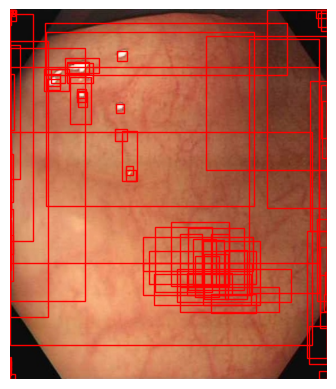

In [11]:
# For inference
model.eval()

# Get a batch of images from the DataLoader
images, targets = next(iter(train_loader))

# Select the first image from the batch for inference
# Assuming your DataLoader returns a batch of images and targets
image_to_infer = images[0].unsqueeze(0).to(device)  # Add batch dimension and move to the device

# Disable gradient computation since we're only doing inference
with torch.no_grad():
    # Perform inference
    predictions = model(image_to_infer)  # Returns predictions

    # Print out the predictions for the first image
    print(predictions[0])
    
# Process the first image and its prediction
image = image_to_infer[0].cpu().numpy()  # Move the tensor to cpu and convert to numpy
image = np.transpose(image, (1, 2, 0))  # Transpose from CxHxW to HxWxC for matplotlib

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis

# Add the predicted bounding boxes
for box in predictions[0]['boxes']:
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

In [12]:
# # After training, you can plot the epoch losses
# plt.plot(epoch_losses, label='Training Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Training Loss Over Epochs')
# plt.legend()
# plt.show()

## Data augmentation

### Data analysis

#### Bounding box analysis

In [34]:
import importlib
import clases.data_utils
importlib.reload(clases.data_utils)
from clases.data_utils import *

In [14]:
# This can take a while to run!
# Assuming train_dataset is an instance of CustomDataset
all_bounding_boxes = get_all_bounding_boxes(train_dataset)
print("Number of bounding boxes:", len(all_bounding_boxes))

Number of bounding boxes: 17930


In [15]:
centers_bbox = get_bbox_centers(all_bounding_boxes)

Elbow method to determine ideal number of clusters

Viendo el gráfico de codo, se puede ver que el número óptimo de clusters es 3.

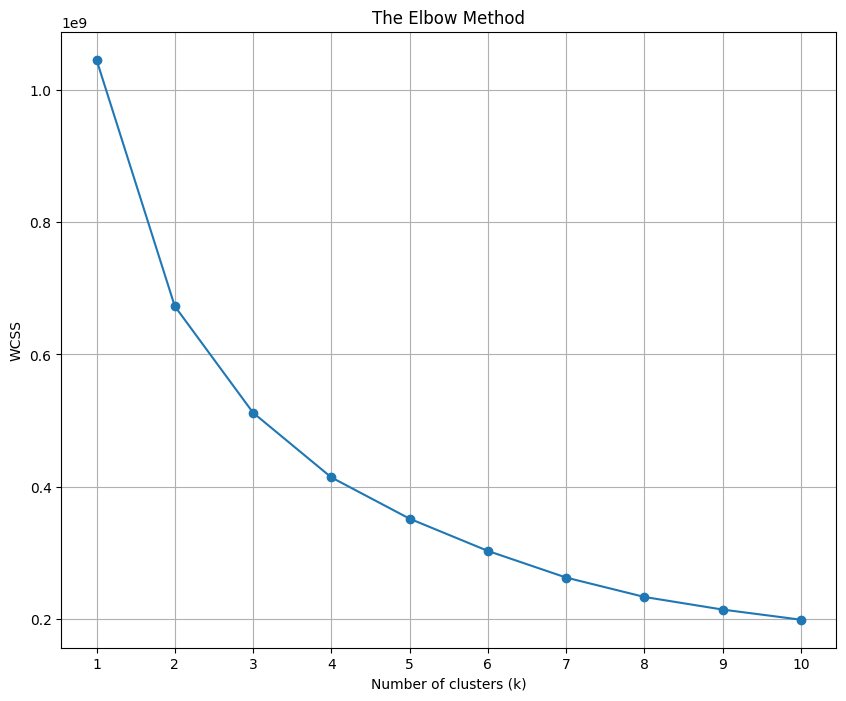

In [16]:
# Calculate WCSS for a range of number of clusters (within-cluster sum of squares)
wcss = calculate_wcss(all_bounding_boxes, max_k=10)
plot_elbow(wcss)

Silhouette score to determine ideal number of clusters (higher is better)

El gráfico de silueta muestra que el número óptimo de clusters es 8 o 6 o quizás 2.
Viendo los resultados del método del codo y el de la silueta, probaremos con 3 y 8 clusters.

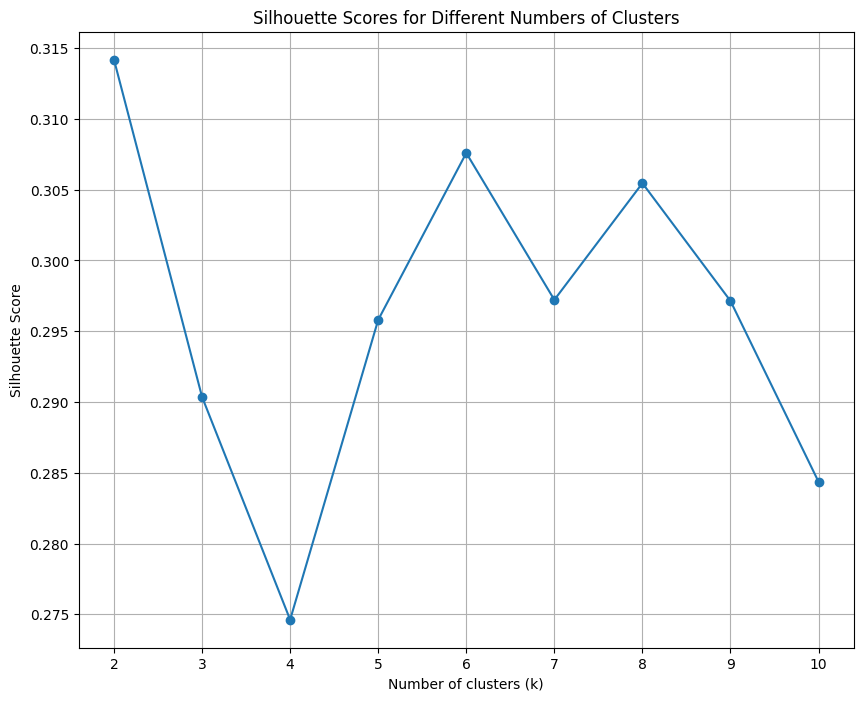

In [17]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for a range of number of clusters
silhouette_scores = calculate_silhouette_scores(all_bounding_boxes, max_k=10)
plot_silhouette_scores(silhouette_scores)

In [18]:
# Use the function with your data
centers_8, labels_8 = cluster_bounding_boxes(all_bounding_boxes,8)
centers_3, labels_3 = cluster_bounding_boxes(all_bounding_boxes,3)
print("Cluster Centers:", centers_8)

C:\Users\pol\anaconda3\envs\TFG\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pol\anaconda3\envs\TFG\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster Centers: [[399.24127  110.90047  483.3912   198.7779  ]
 [229.02133  194.50017  329.7833   287.5275  ]
 [233.94518  335.48395  346.82397  419.0286  ]
 [ 56.17729   89.79008  165.33868  234.78468 ]
 [383.28488  281.80618  477.25986  380.35736 ]
 [ 84.00452  260.17755  188.21378  376.65115 ]
 [155.83334   79.52644  482.15125  437.5247  ]
 [177.69638   54.127777 315.2286   133.20433 ]]


Los centros de los clústeres parecen estar distribuidos de forma equidistante, lo que nos indica que los clústeres están bien distribuidos.

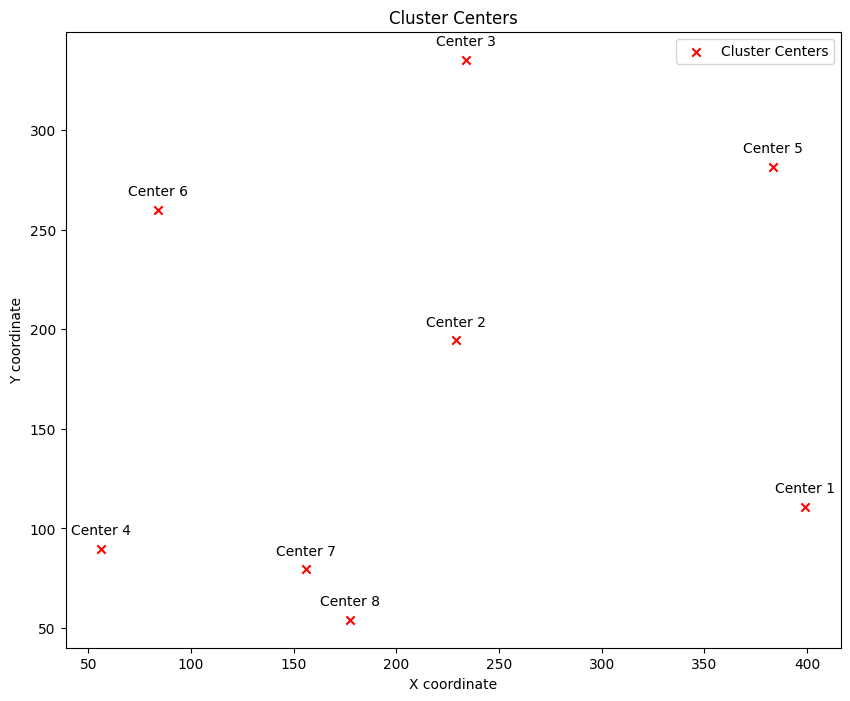

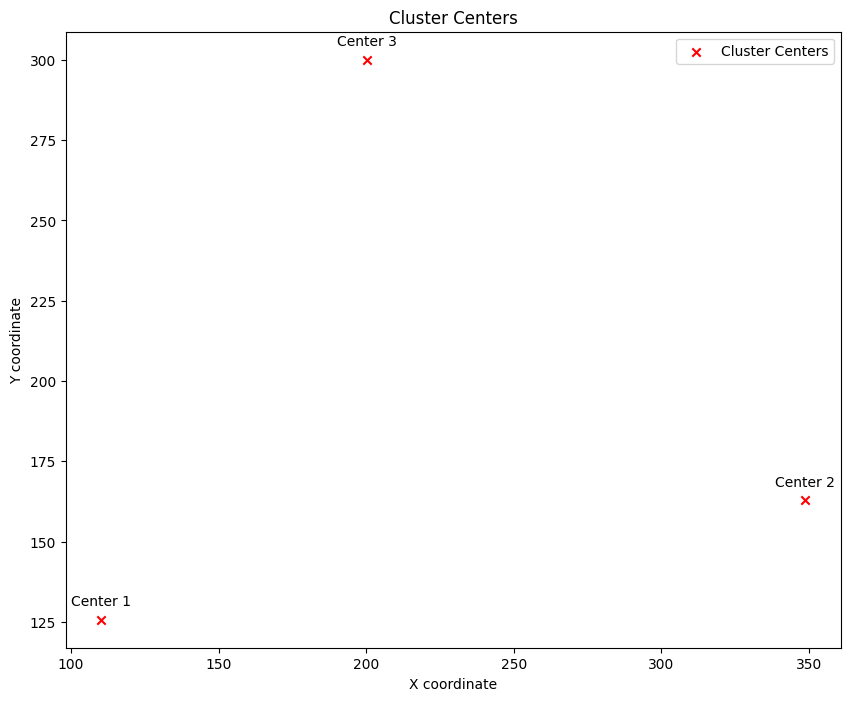

In [19]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
plot_cluster_centers(centers_8)
plot_cluster_centers(centers_3)


 Para poder visualizar mejor los datos mostraremos los centros de los clústeres y los centros de los bounding boxes en la misma imagen. Esto nos permitirá ver si los centros de los clústeres se encuentran cerca de los centros de los bounding boxes.
 
Parece que los centros de los clústeres se encuentran cerca de los centros de los bounding boxes, pero no podemos verlo bien porque hay muchos centros de bounding boxes.
Parece que al haver tantos centros de bounding boxes, no podemos ver la cantidad de centros de clústeres que hay. Por lo que sería interesante provar con un gráfico de densidad.

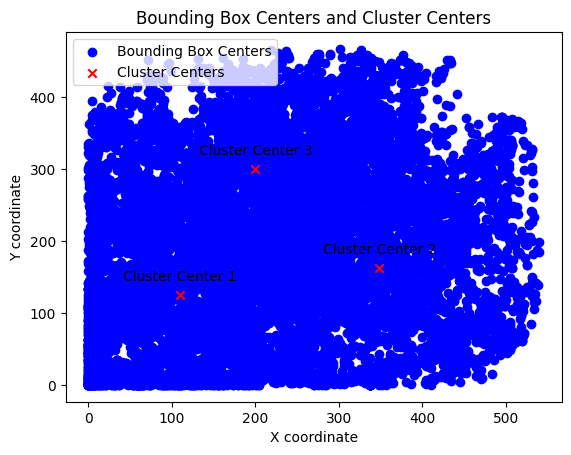

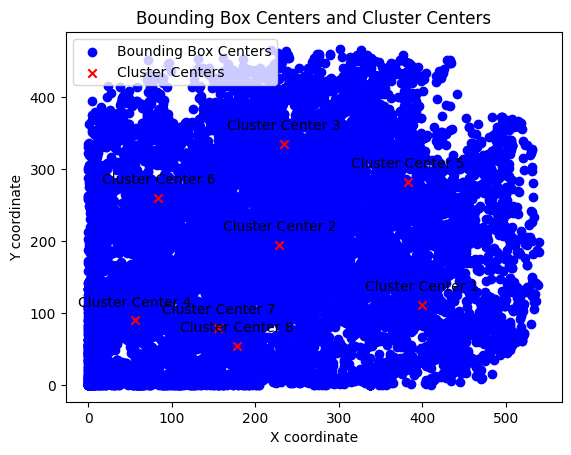

In [37]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
# Also, assume that `bounding_boxes` contains your bounding box data.
plot_cluster_centers_with_bbox_centers(centers_3, all_bounding_boxes)
plot_cluster_centers_with_bbox_centers(centers_8, all_bounding_boxes)


También és de utilidad mostrar la densidad de los centros de los bounding boxes para hacerse una mejor idea de donde caen los centros de las cajas. Podríamos pensar que los centros de las cajas se encuentran alrededor de los bordes de las imágenes por la morfologia de las colonoscopias, pero no es así.
De hecho si nos fijamos en el gráfico de densidad de los centros de las cajas, podemos ver que se encuentran en el centro de las imágenes.

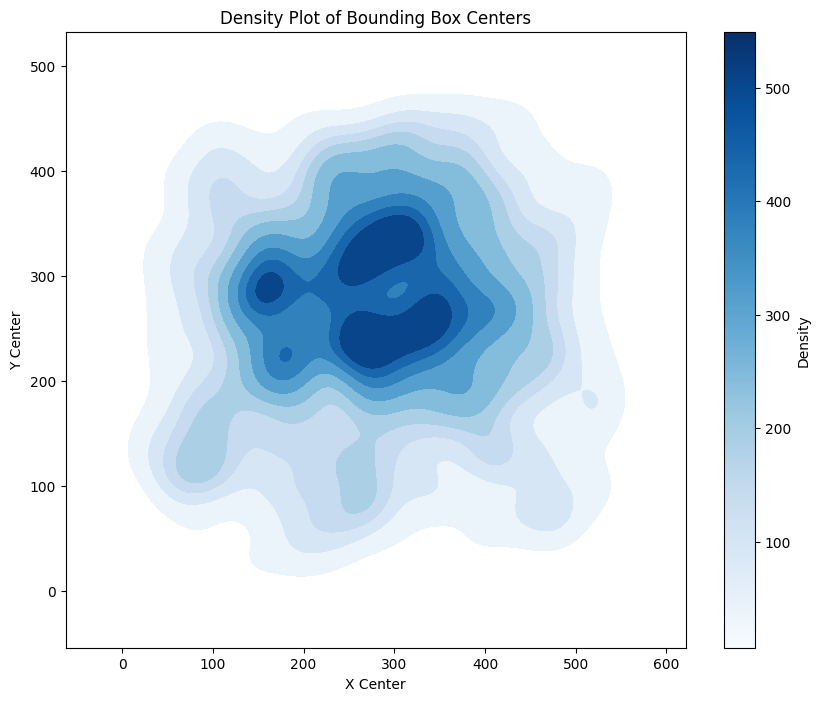

In [33]:
plot_density_of_bbox_centers(centers_bbox)


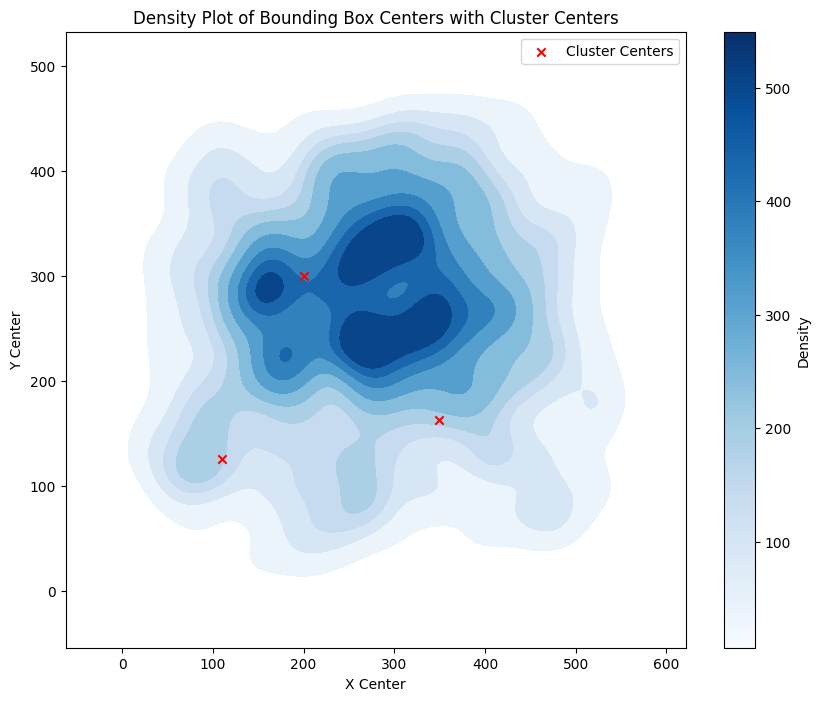

In [35]:
plot_density_of_bbox_centers_with_clusters(centers_bbox,centers_3)

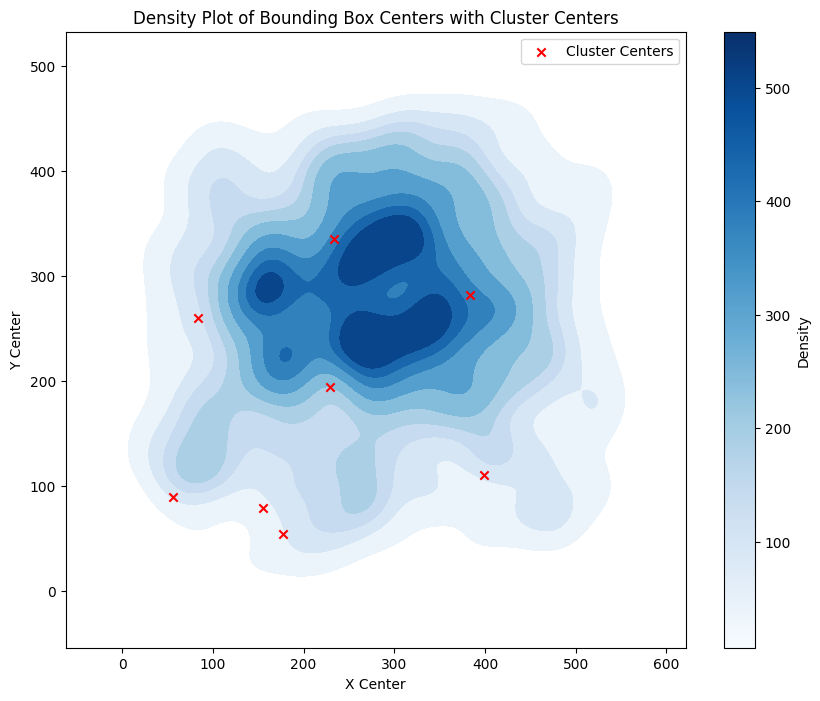

In [36]:
plot_density_of_bbox_centers_with_clusters(centers_bbox, centers_8)